In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import classification_report , confusion_matrix
from sklearn import metrics


import warnings

In [2]:
warnings.simplefilter(action="ignore")
plt.style.use("seaborn")

In [3]:
data = pd.read_csv("diabetes.csv")
df = pd.DataFrame(data)
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


<div style="
  margin: 30px 0;
  padding: 20px 24px;
  background: #f8fafc;
  border-left: 5px solid #3b82f6;
  border-radius: 8px;
  font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
  color: #1e293b;
  line-height: 1.7;
">
  <h3 style="
    margin: 0 0 16px 0;
    font-size: 20px;
    font-weight: 700;
    color: #1e3a8a;
  ">
    About Features
  </h3>

  <ul style="margin: 0; padding-left: 20px; font-size: 15px;">
    <li><strong>Pregnancies</strong> → Number of pregnancies</li>
    <li><strong>Glucose</strong> → Glucose level</li>
    <li><strong>BloodPressure</strong> → Blood pressure</li>
    <li><strong>SkinThickness</strong> → Skin thickness</li>
    <li><strong>Insulin</strong> → Insulin level</li>
    <li><strong>BMI</strong> → Body Mass Index: Measures the ratio of height to weight to estimate body fat</li>
    <li><strong>DiabetesPedigreeFunction</strong> → Diabetes pedigree function</li>
    <li><strong>Age</strong> → Age</li>
    <li><strong>Outcome</strong> → Target variable. 1 means the person has diabetes, 0 means the person does not have diabetes</li>
  </ul>
</div>

In [5]:
df.head(50)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [6]:
df.tail(50)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
718,1,108,60,46,178,35.5,0.415,24,0
719,5,97,76,27,0,35.6,0.378,52,1
720,4,83,86,19,0,29.3,0.317,34,0
721,1,114,66,36,200,38.1,0.289,21,0
722,1,149,68,29,127,29.3,0.349,42,1
723,5,117,86,30,105,39.1,0.251,42,0
724,1,111,94,0,0,32.8,0.265,45,0
725,4,112,78,40,0,39.4,0.236,38,0
726,1,116,78,29,180,36.1,0.496,25,0
727,0,141,84,26,0,32.4,0.433,22,0


In [7]:
df.describe(include="all")

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [8]:
df[df.duplicated()]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome


In [9]:
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [11]:
df1 = df.sort_values(by ="Age")
df1.reset_index(inplace=True)
df1

,index,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,255,1,113,64,35,0,33.6,0.543,21,1
1,60,2,84,0,0,0,0.0,0.304,21,0
2,102,0,125,96,0,0,22.5,0.262,21,0
3,182,1,0,74,20,23,27.7,0.299,21,0
4,623,0,94,70,27,115,43.5,0.347,21,0
...,...,...,...,...,...,...,...,...,...,...
763,123,5,132,80,0,0,26.8,0.186,69,0
764,684,5,136,82,0,0,0.0,0.640,69,0
765,666,4,145,82,18,0,32.5,0.235,70,1
766,453,2,119,0,0,0,19.6,0.832,72,0


In [12]:
df1.drop("index",axis=1 , inplace=True)
df1

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,1,113,64,35,0,33.6,0.543,21,1
1,2,84,0,0,0,0.0,0.304,21,0
2,0,125,96,0,0,22.5,0.262,21,0
3,1,0,74,20,23,27.7,0.299,21,0
4,0,94,70,27,115,43.5,0.347,21,0
...,...,...,...,...,...,...,...,...,...
763,5,132,80,0,0,26.8,0.186,69,0
764,5,136,82,0,0,0.0,0.640,69,0
765,4,145,82,18,0,32.5,0.235,70,1
766,2,119,0,0,0,19.6,0.832,72,0


<div style="
  margin: 40px 0 25px 0;
  text-align: center;
  font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
">
  <h2 style="
    font-size: 24px;
    font-weight: 700;
    color: #1e3a8a;
    margin: 0 0 10px 0;
    letter-spacing: 0.3px;
  ">
    Univariate Analysis
  </h2>
  <div style="
    width: 150px;
    height: 4px;
    background: linear-gradient(90deg, #3b82f6, #8b5cf6);
    margin: 0 auto;
    border-radius: 4px;
  "></div>
</div>

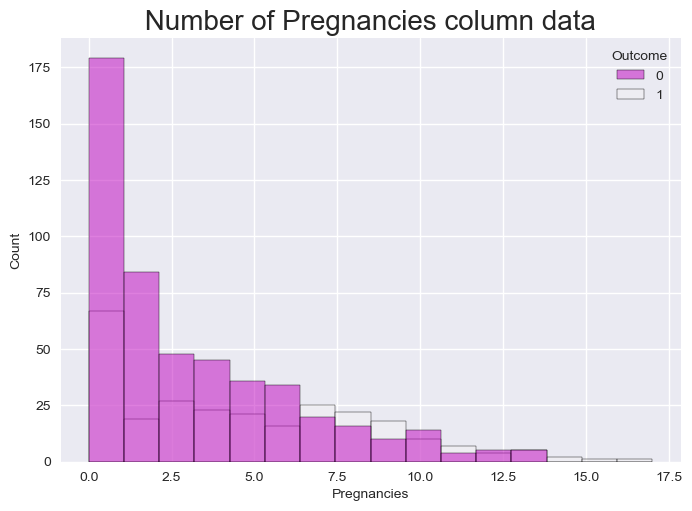

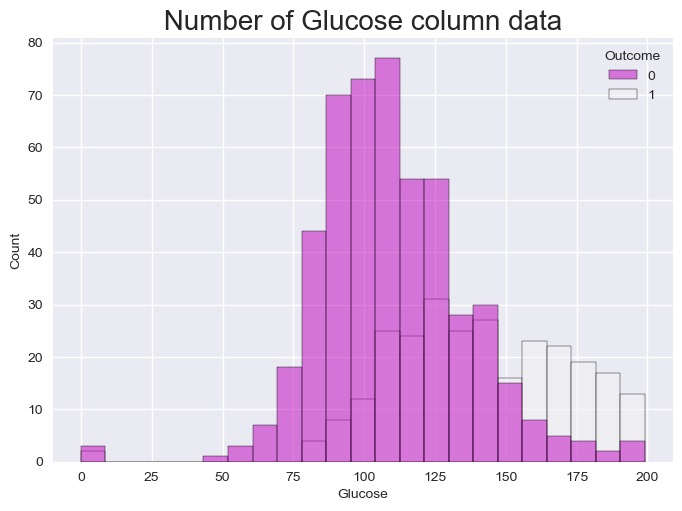

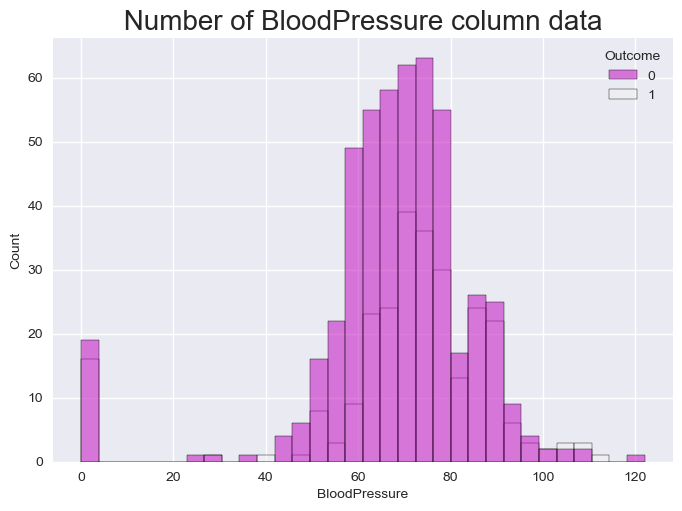

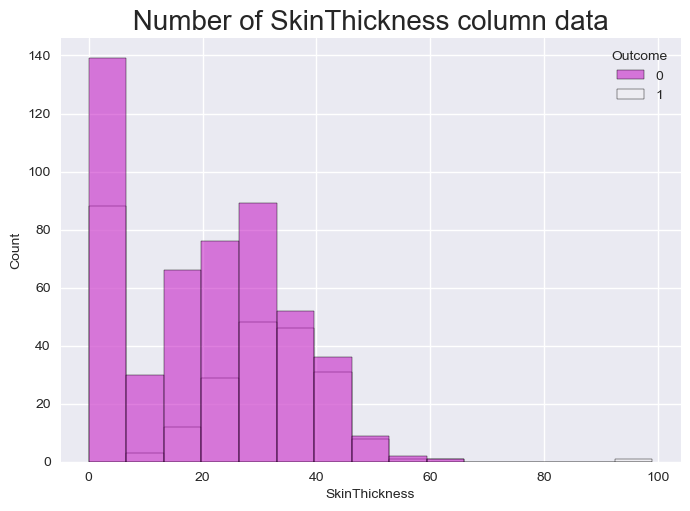

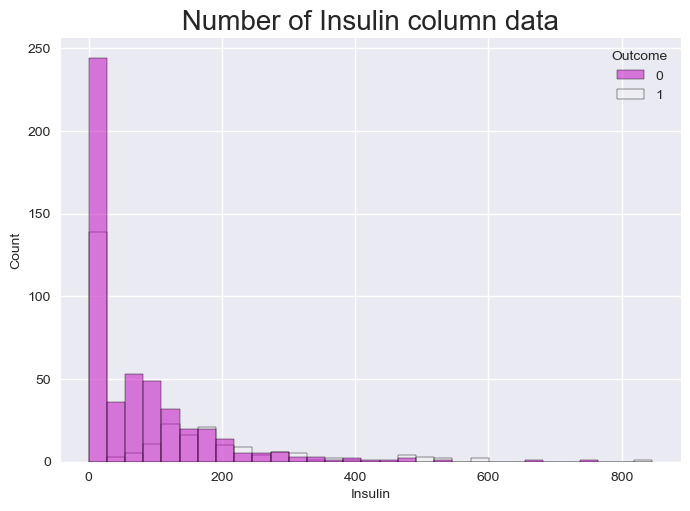

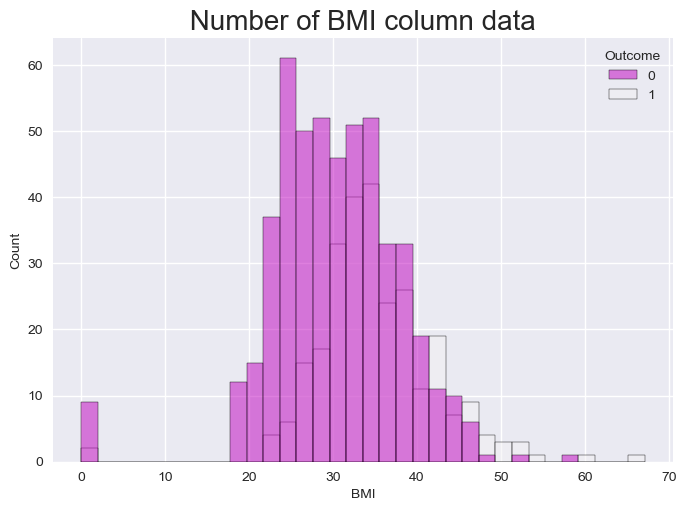

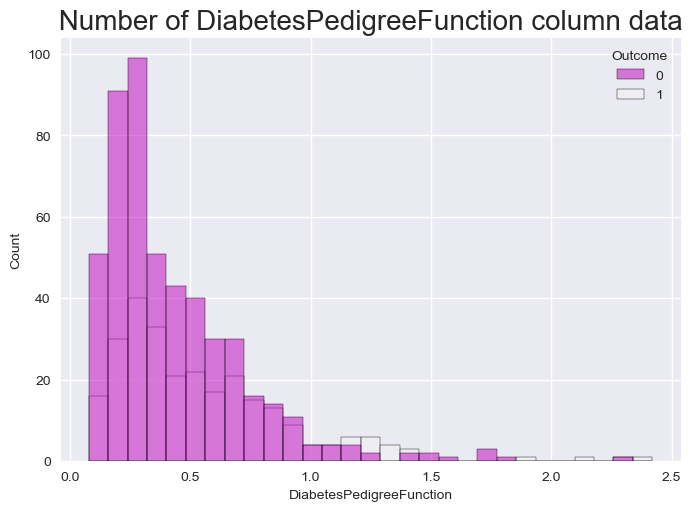

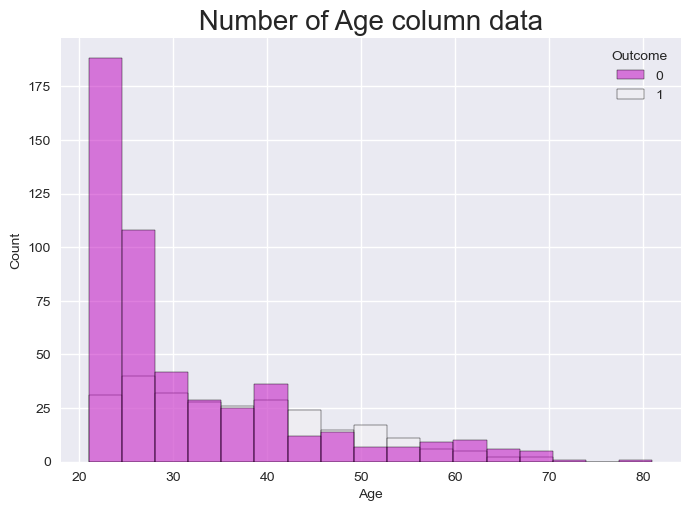

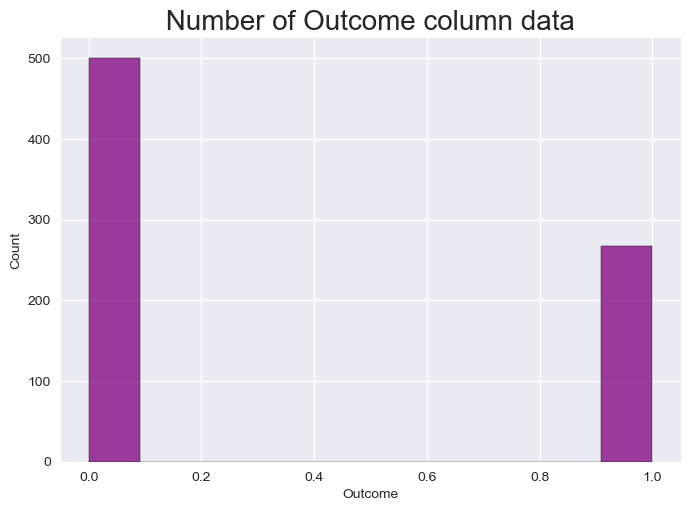

In [14]:
sns.histplot(df1 ,x = "Pregnancies" , hue="Outcome"  , palette="light:m_r")
plt.title(" Number of Pregnancies column data " , fontsize=20)
plt.show()

# ---------------------------------------------------------------------------------------------------
sns.histplot(df1 ,x = "Glucose" , hue="Outcome"  , palette="light:m_r")
plt.title(" Number of Glucose column data " , fontsize=20)
plt.show()

# ---------------------------------------------------------------------------------------------------

sns.histplot(df1 ,x = "BloodPressure" , hue="Outcome"  , palette="light:m_r")
plt.title(" Number of BloodPressure column data " , fontsize=20)
plt.show()

# ---------------------------------------------------------------------------------------------------

sns.histplot(df1 ,x = "SkinThickness" , hue="Outcome"  , palette="light:m_r")
plt.title(" Number of SkinThickness column data " , fontsize=20)
plt.show()

# ---------------------------------------------------------------------------------------------------

sns.histplot(df1 ,x = "Insulin" , hue="Outcome"  , palette="light:m_r")
plt.title(" Number of Insulin column data " , fontsize=20)
plt.show()

# ---------------------------------------------------------------------------------------------------

sns.histplot(df1 ,x = "BMI" , hue="Outcome"  , palette="light:m_r")
plt.title(" Number of BMI column data " , fontsize=20)
plt.show()

# ---------------------------------------------------------------------------------------------------

sns.histplot(df1 ,x = "DiabetesPedigreeFunction" , hue="Outcome"  , palette="light:m_r")
plt.title(" Number of DiabetesPedigreeFunction column data " , fontsize=20)
plt.show()

# ---------------------------------------------------------------------------------------------------

sns.histplot(df1 ,x = "Age" , hue="Outcome"  , palette="light:m_r")
plt.title(" Number of Age column data " , fontsize=20)
plt.show()

# ---------------------------------------------------------------------------------------------------

sns.histplot(df1 ,x = "Outcome"  , color="Purple")
plt.title(" Number of Outcome column data " , fontsize=20)
plt.show()



<div style="
  margin: 40px 0 25px 0;
  text-align: center;
  font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
">
  <h2 style="
    font-size: 24px;
    font-weight: 700;
    color: #1e3a8a;
    margin: 0 0 10px 0;
    letter-spacing: 0.3px;
  ">
    Bivariate Analysis
  </h2>
  <div style="
    width: 150px;
    height: 4px;
    background: linear-gradient(90deg, #3b82f6, #8b5cf6);
    margin: 0 auto;
    border-radius: 4px;
  "></div>
</div>

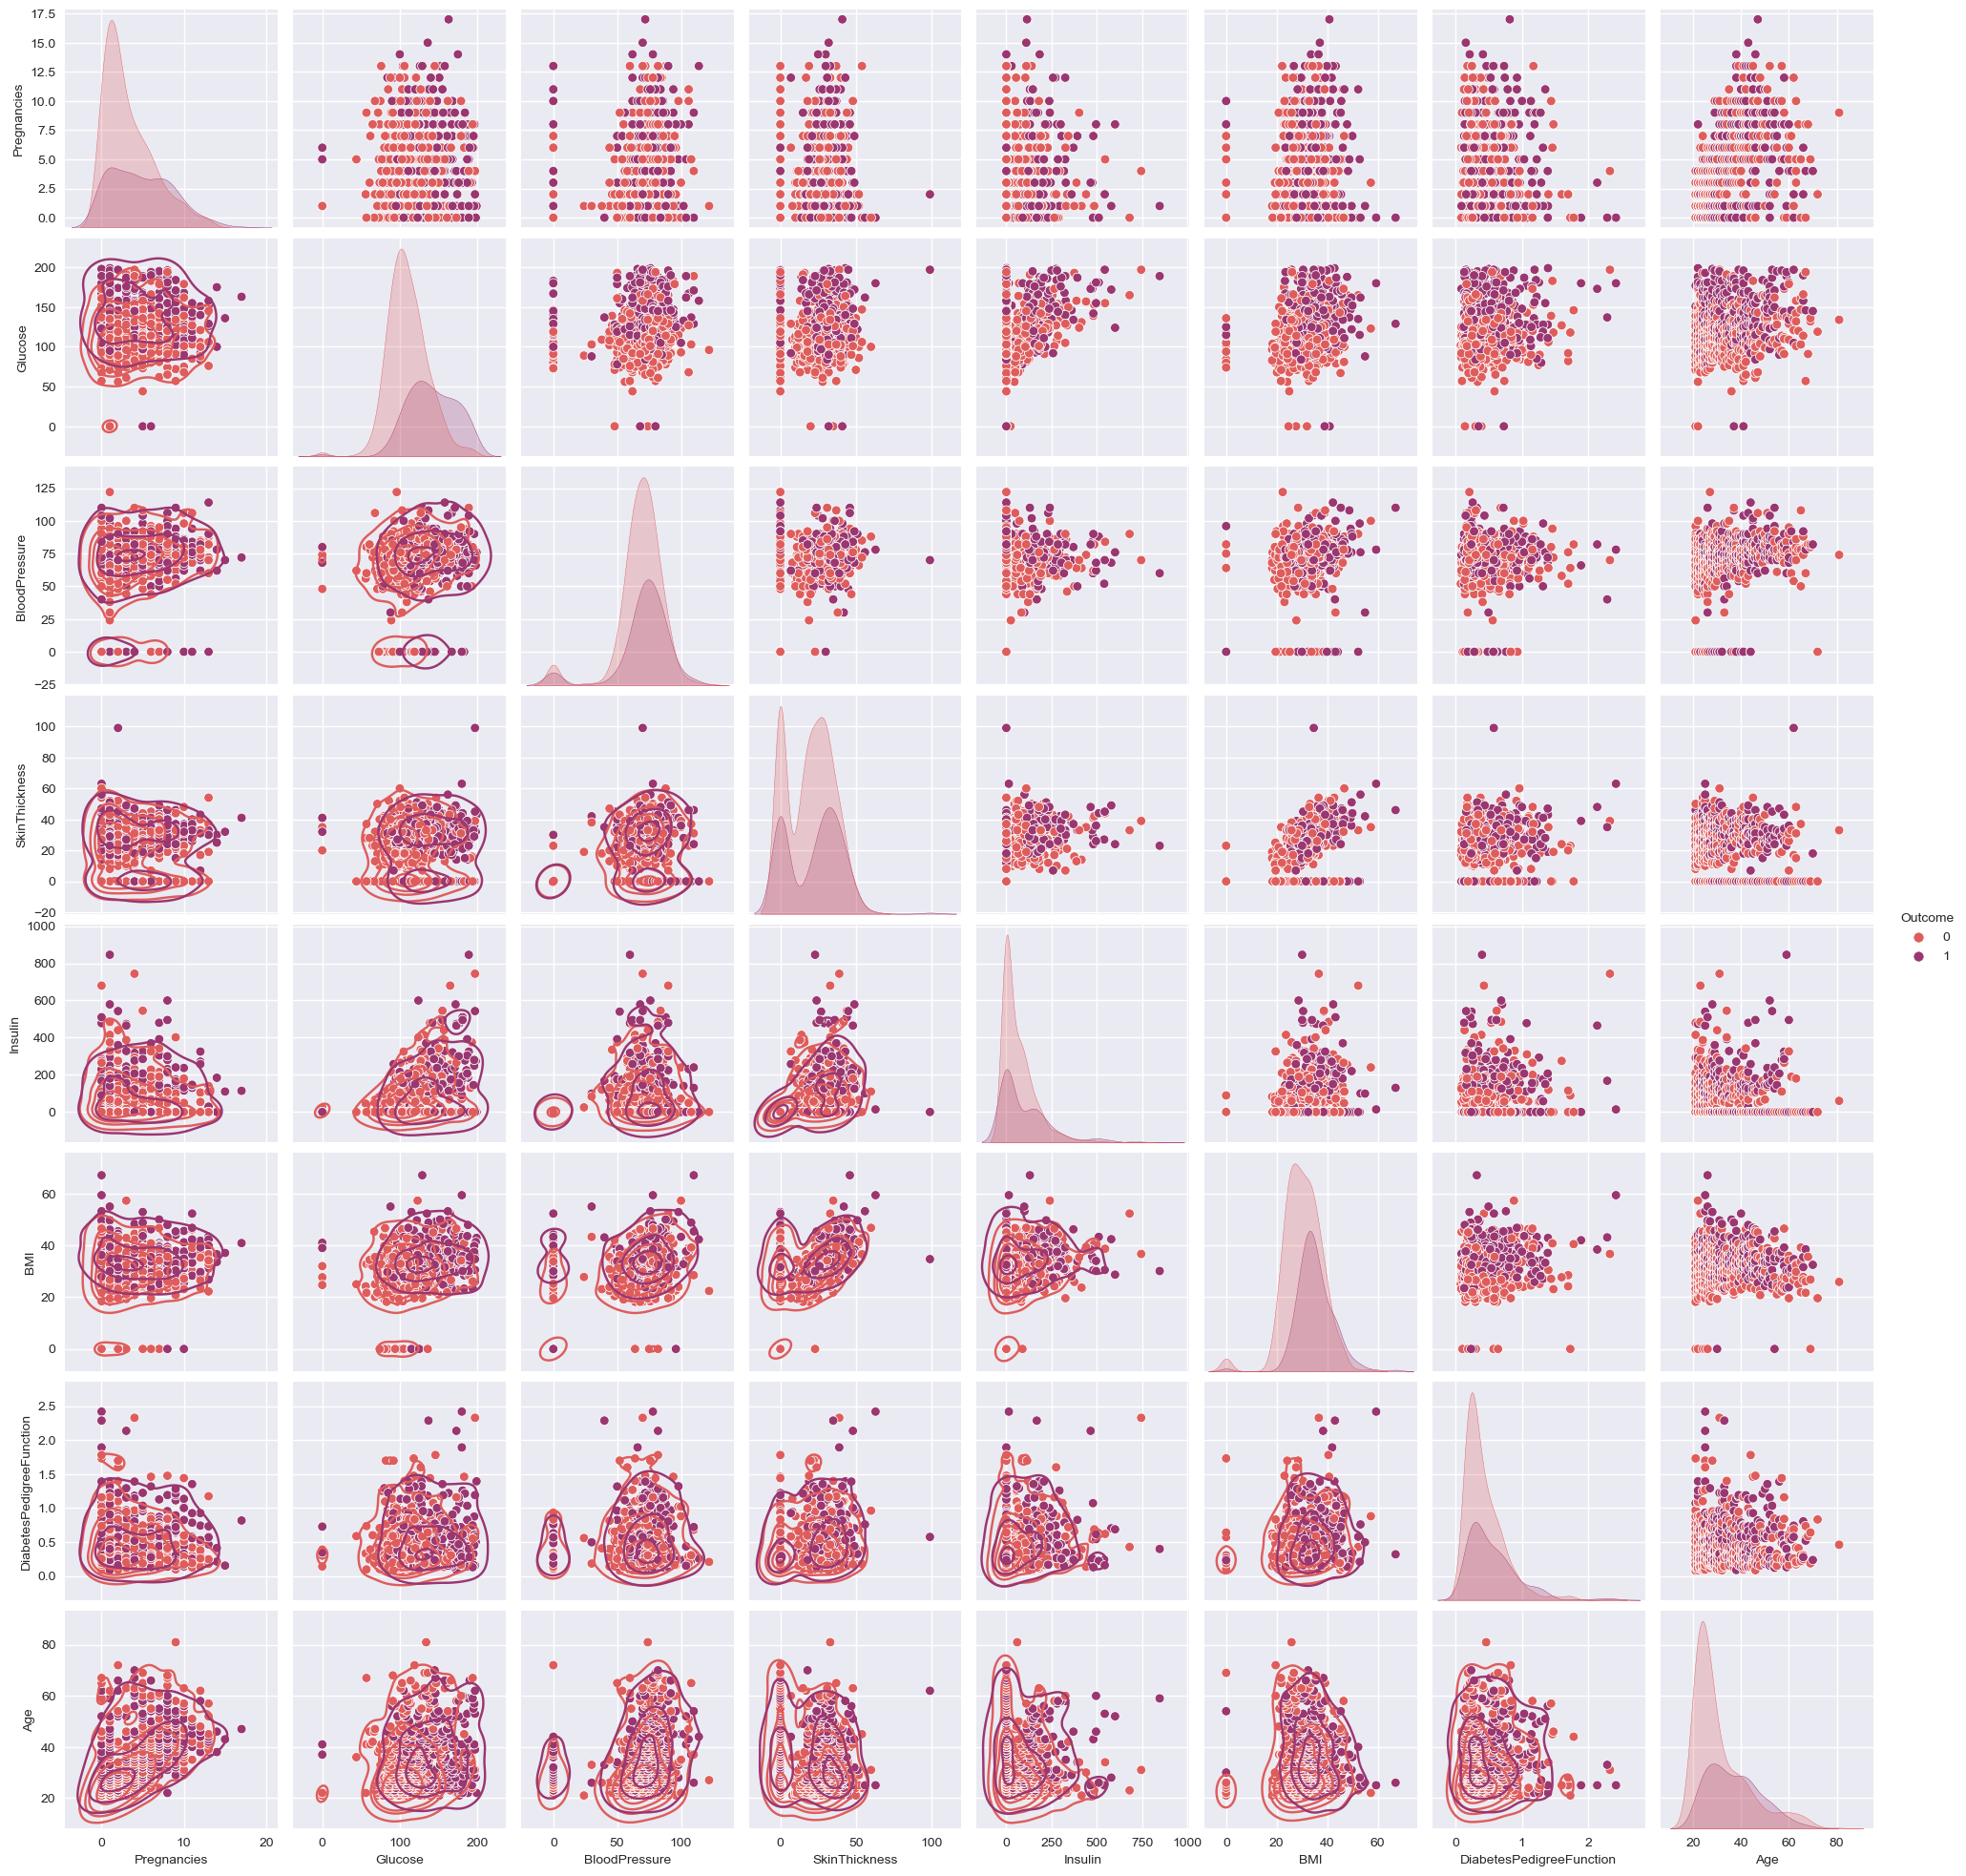

In [16]:

g = sns.pairplot(df1, hue="Outcome" , diag_kind="kde" , palette = "flare")
g.map_lower(sns.kdeplot, levels = 5 , color=".2")


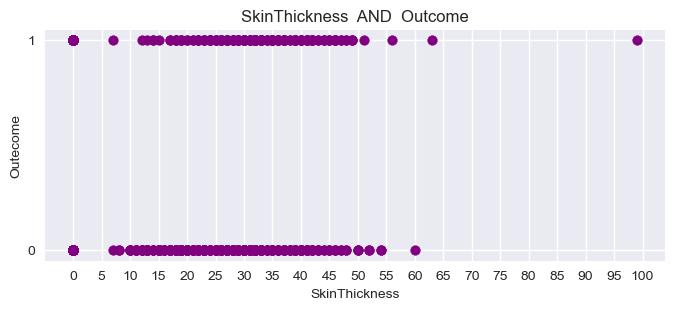

In [17]:
plt.figure(figsize=(8 ,3) )
plt.grid(True)

plt.scatter(df1["SkinThickness"] , df1["Outcome"]  ,color="Purple"  )

plt.title("SkinThickness  AND  Outcome")
plt.xlabel("SkinThickness")
plt.ylabel("Outecome")

plt.xticks(np.arange(0,105,5))
plt.yticks(np.arange(0,2,1))

plt.show()

In [18]:
# Skin Thickness >95  seems to be noise . 
#  Skin Thickness < 95

# The rest is normal

In [19]:
df2 = df1[df1["SkinThickness"]<95]
df2

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,1,113,64,35,0,33.6,0.543,21,1
1,2,84,0,0,0,0.0,0.304,21,0
2,0,125,96,0,0,22.5,0.262,21,0
3,1,0,74,20,23,27.7,0.299,21,0
4,0,94,70,27,115,43.5,0.347,21,0
...,...,...,...,...,...,...,...,...,...
763,5,132,80,0,0,26.8,0.186,69,0
764,5,136,82,0,0,0.0,0.640,69,0
765,4,145,82,18,0,32.5,0.235,70,1
766,2,119,0,0,0,19.6,0.832,72,0


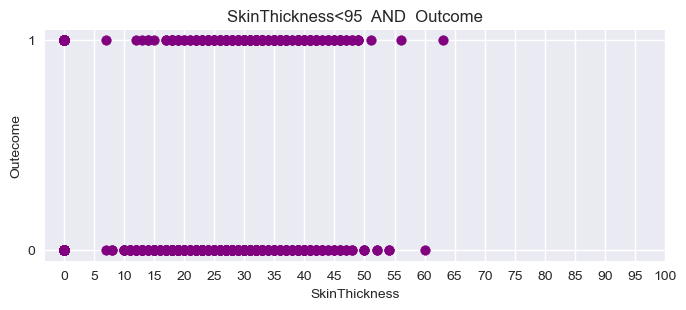

In [20]:
plt.figure(figsize=(8 ,3) )
plt.grid(True)

plt.scatter(df2["SkinThickness"] , df2["Outcome"]  ,color="Purple"  )

plt.title("SkinThickness<95  AND  Outcome")
plt.xlabel("SkinThickness")
plt.ylabel("Outecome")

plt.xticks(np.arange(0,105,5))
plt.yticks(np.arange(0,2,1))

plt.show()

<div style="
  margin: 25px 0;
  padding: 14px 18px;
  background: #ecfdf5;
  border-left: 5px solid #10b981;
  border-radius: 6px;
  font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
  font-size: 16px;
  color: #065f46;
  line-height: 1.5;
">
  <strong>Result:</strong> The dataset was cleaned.
</div>

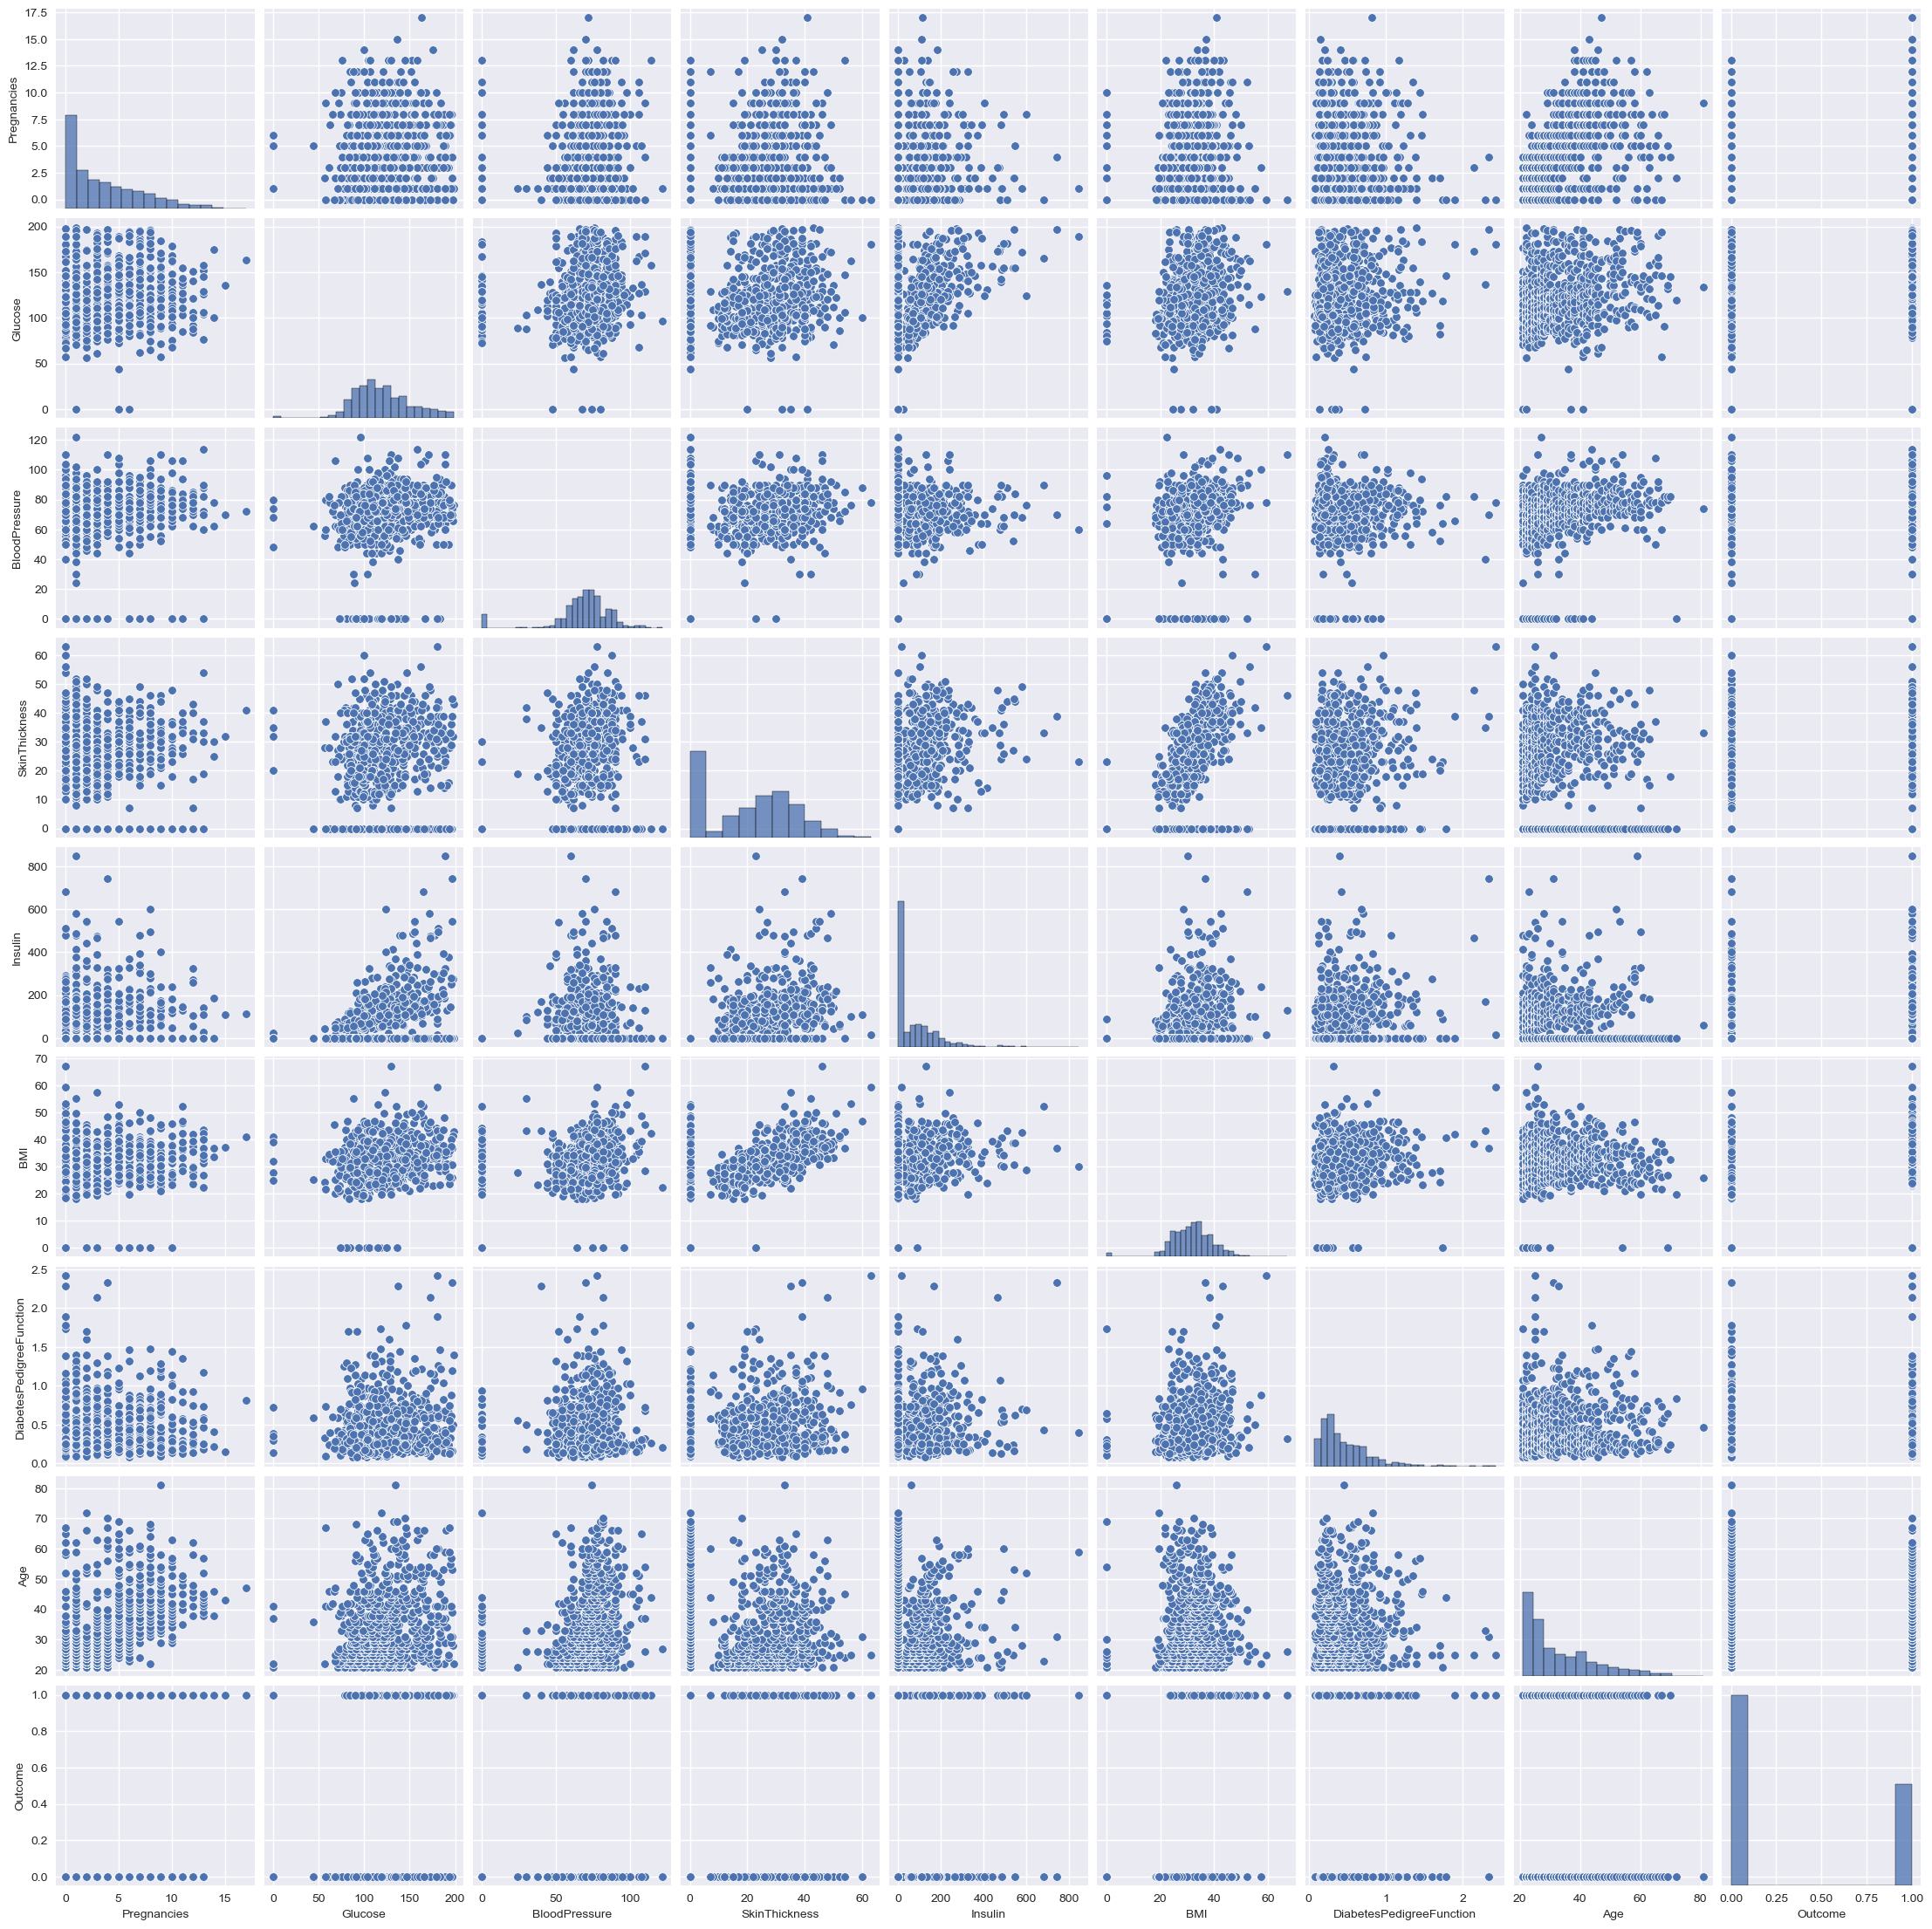

In [21]:
sns.pairplot(df2 )

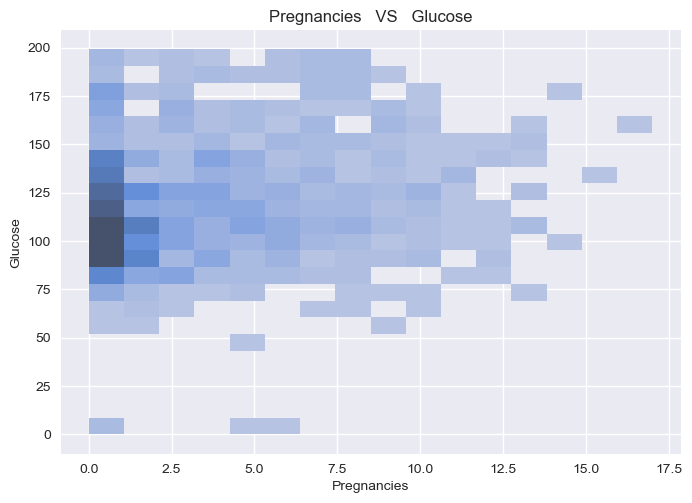

-----------------------------------------------------------------------------------------


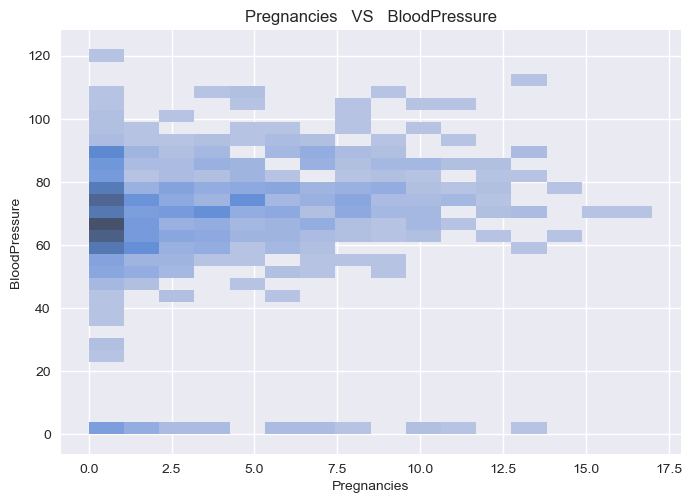

-----------------------------------------------------------------------------------------


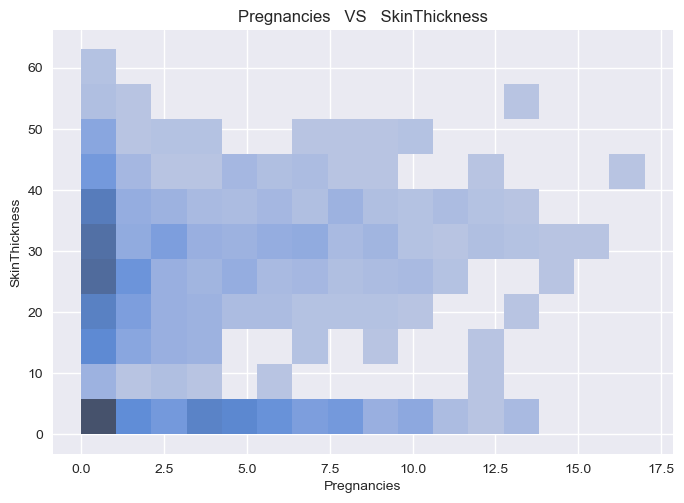

-----------------------------------------------------------------------------------------


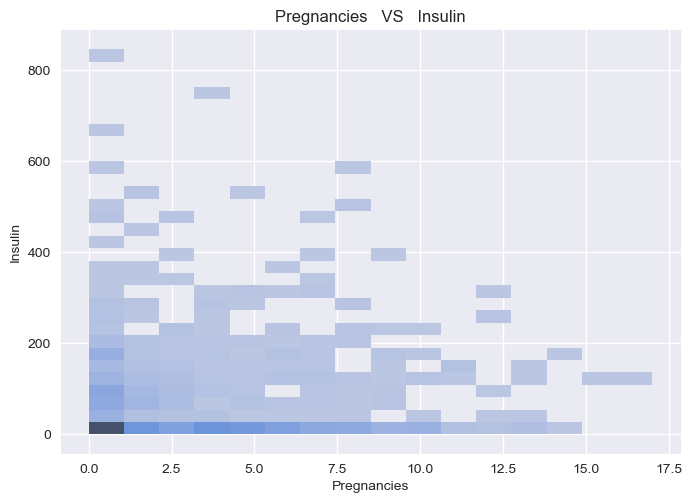

-----------------------------------------------------------------------------------------


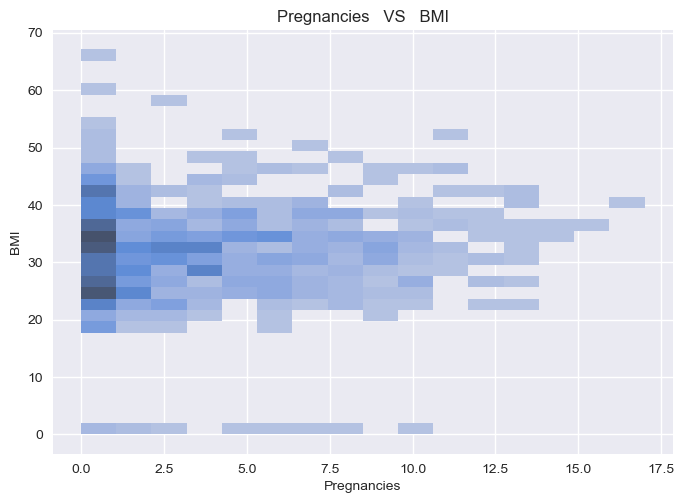

-----------------------------------------------------------------------------------------


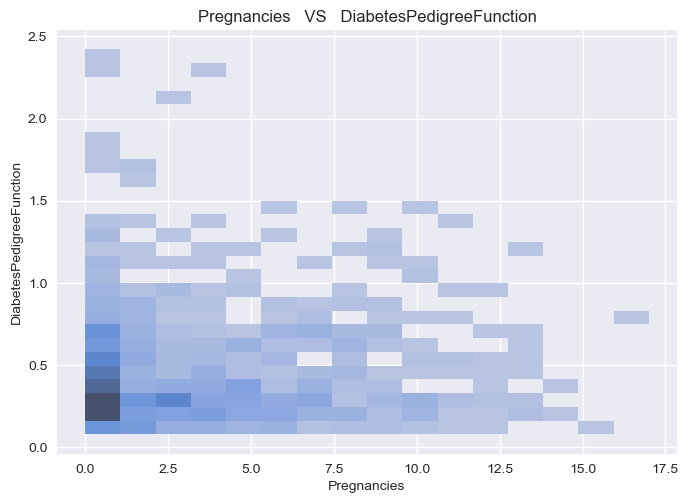

-----------------------------------------------------------------------------------------


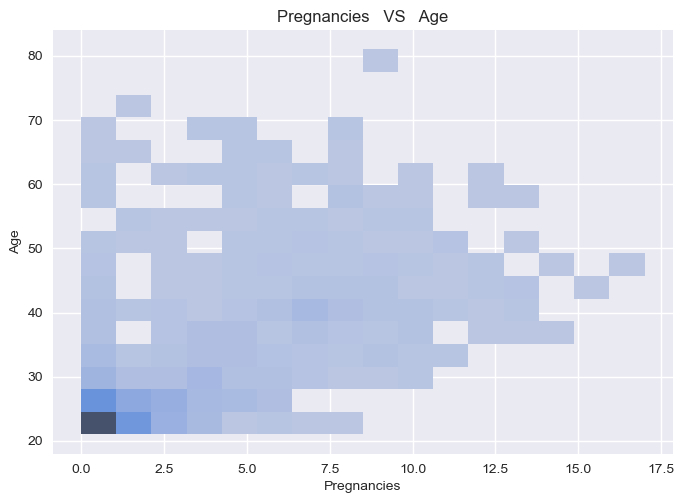

-----------------------------------------------------------------------------------------


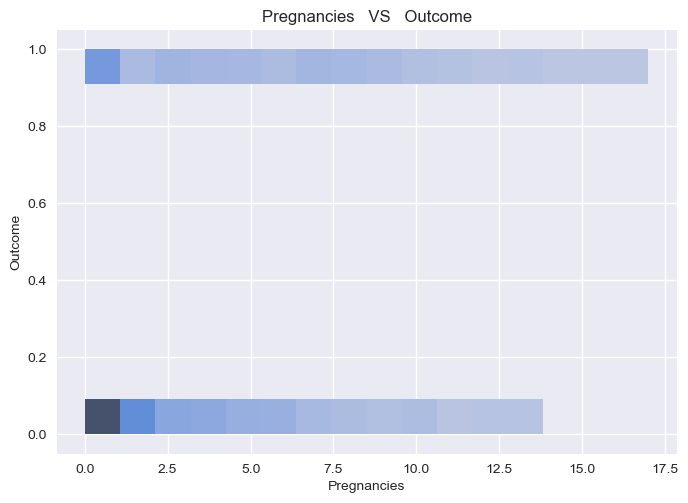

-----------------------------------------------------------------------------------------


In [22]:
sns.histplot(df2 , x="Pregnancies" , y="Glucose")
plt.title("Pregnancies   VS   Glucose")
plt.show()
print("-----------------------------------------------------------------------------------------")


sns.histplot(df2 , x="Pregnancies" , y="BloodPressure")
plt.title("Pregnancies   VS   BloodPressure")

plt.show()
print("-----------------------------------------------------------------------------------------")

sns.histplot(df2 , x="Pregnancies" , y="SkinThickness")
plt.title("Pregnancies   VS   SkinThickness")

plt.show()
print("-----------------------------------------------------------------------------------------")


sns.histplot(df2 , x="Pregnancies" , y="Insulin")
plt.title("Pregnancies   VS   Insulin")

plt.show()
print("-----------------------------------------------------------------------------------------")


sns.histplot(df2 , x="Pregnancies" , y="BMI")
plt.title("Pregnancies   VS   BMI")

plt.show()
print("-----------------------------------------------------------------------------------------")


sns.histplot(df2 , x="Pregnancies" , y="DiabetesPedigreeFunction")
plt.title("Pregnancies   VS   DiabetesPedigreeFunction")

plt.show()
print("-----------------------------------------------------------------------------------------")


sns.histplot(df2 , x="Pregnancies" , y="Age")
plt.title("Pregnancies   VS   Age")

plt.show()
print("-----------------------------------------------------------------------------------------")


sns.histplot(df2 , x="Pregnancies" , y="Outcome")
plt.title("Pregnancies   VS   Outcome")

plt.show()
print("-----------------------------------------------------------------------------------------")


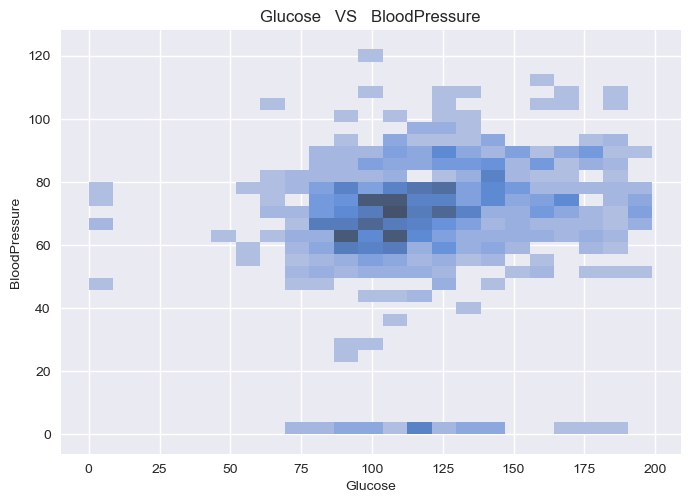

-----------------------------------------------------------------------------------------


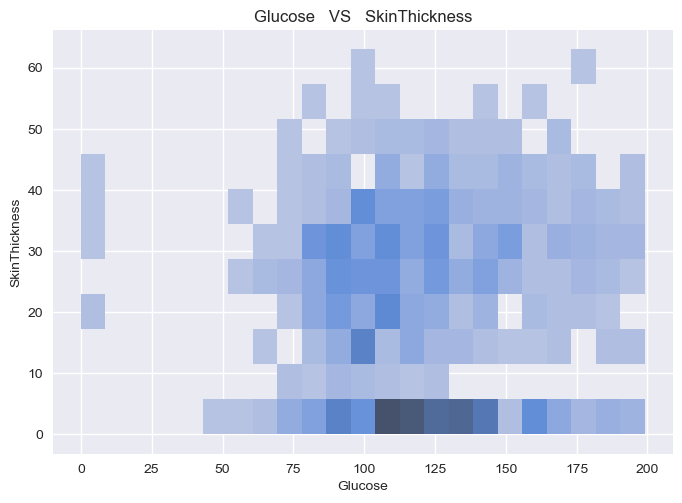

-----------------------------------------------------------------------------------------


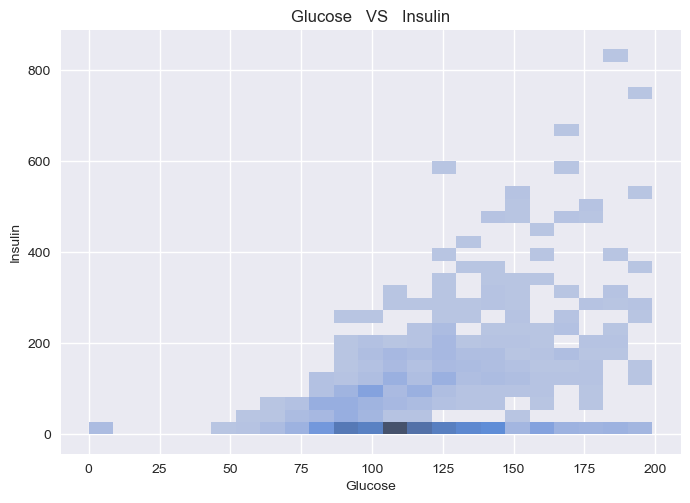

-----------------------------------------------------------------------------------------


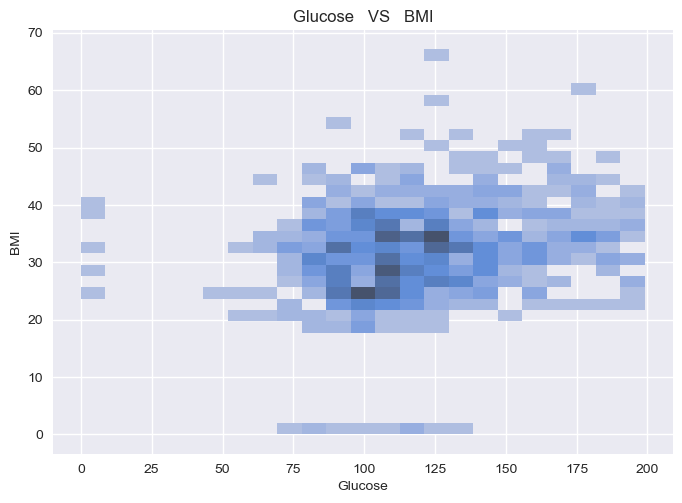

-----------------------------------------------------------------------------------------


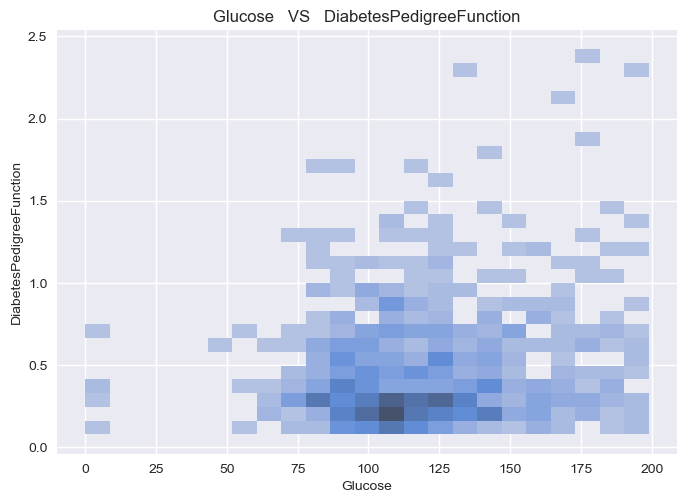

-----------------------------------------------------------------------------------------


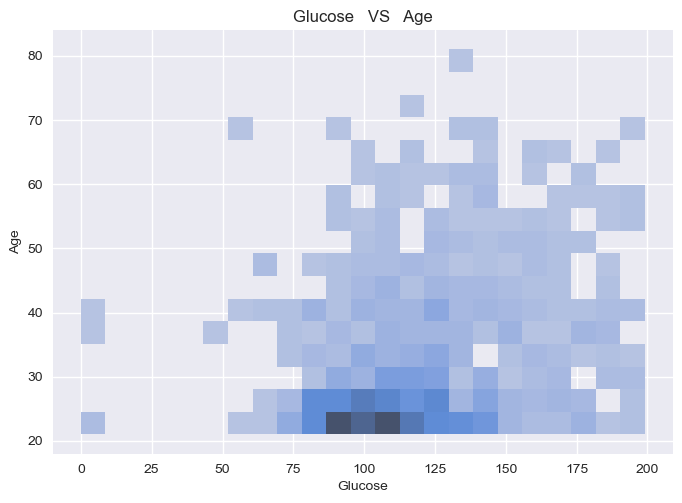

-----------------------------------------------------------------------------------------


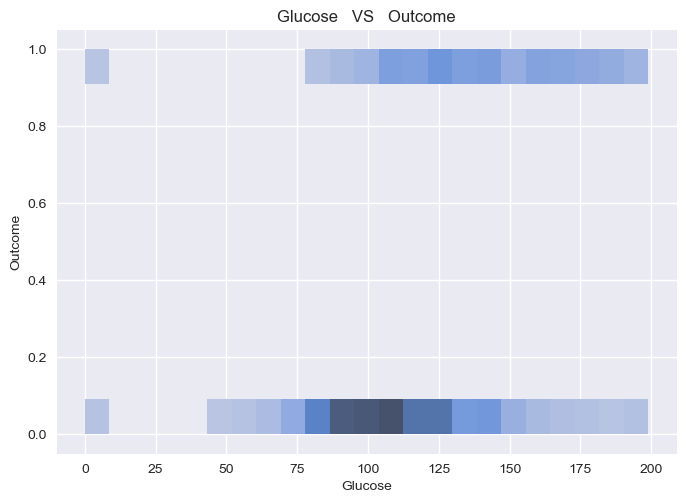

-----------------------------------------------------------------------------------------


In [23]:


sns.histplot(df2 , x="Glucose" , y="BloodPressure")
plt.title("Glucose   VS   BloodPressure")

plt.show()
print("-----------------------------------------------------------------------------------------")

sns.histplot(df2 , x="Glucose" , y="SkinThickness")
plt.title("Glucose   VS   SkinThickness")

plt.show()
print("-----------------------------------------------------------------------------------------")


sns.histplot(df2 , x="Glucose" , y="Insulin")
plt.title("Glucose   VS   Insulin")

plt.show()
print("-----------------------------------------------------------------------------------------")


sns.histplot(df2 , x="Glucose" , y="BMI")
plt.title("Glucose   VS   BMI")

plt.show()
print("-----------------------------------------------------------------------------------------")


sns.histplot(df2 , x="Glucose" , y="DiabetesPedigreeFunction")
plt.title("Glucose   VS   DiabetesPedigreeFunction")

plt.show()
print("-----------------------------------------------------------------------------------------")


sns.histplot(df2 , x="Glucose" , y="Age")
plt.title("Glucose   VS   Age")

plt.show()
print("-----------------------------------------------------------------------------------------")


sns.histplot(df2 , x="Glucose" , y="Outcome")
plt.title("Glucose   VS   Outcome")

plt.show()
print("-----------------------------------------------------------------------------------------")


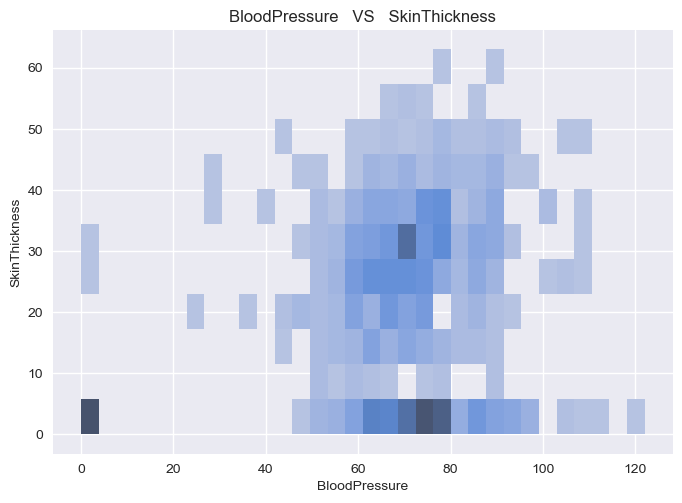

-----------------------------------------------------------------------------------------


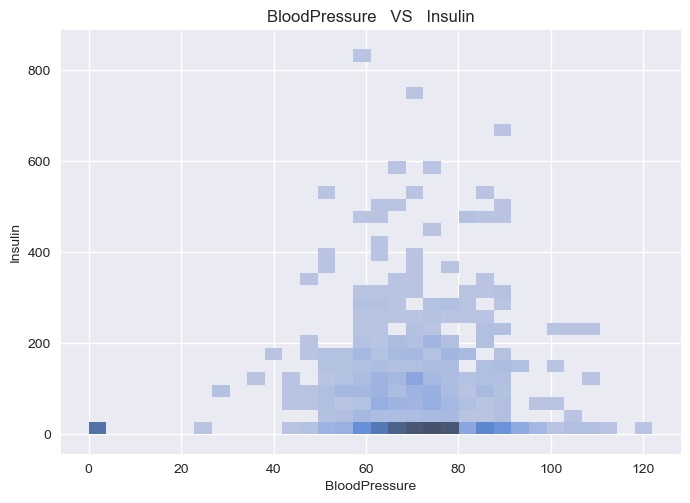

-----------------------------------------------------------------------------------------


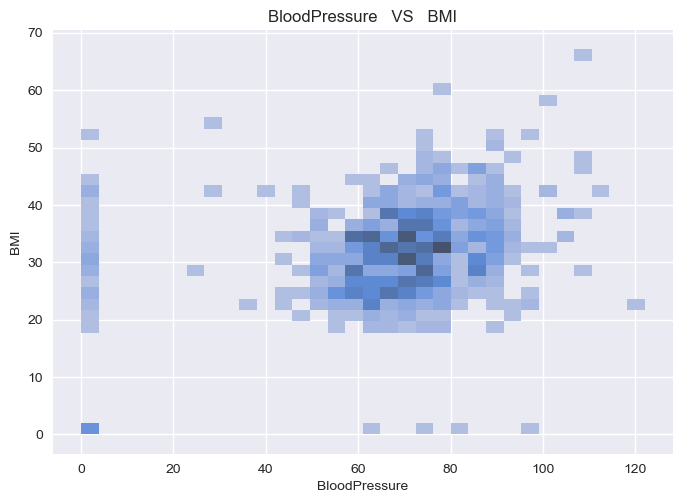

-----------------------------------------------------------------------------------------


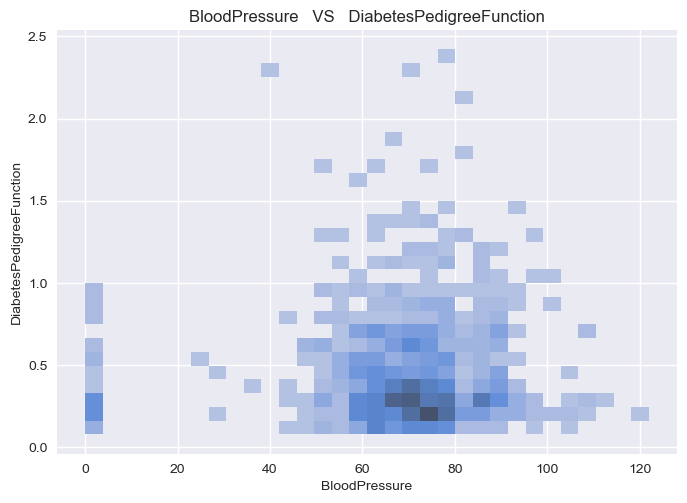

-----------------------------------------------------------------------------------------


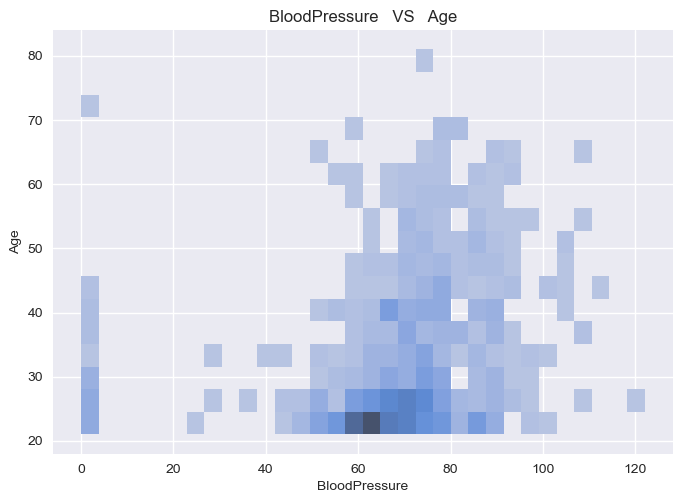

-----------------------------------------------------------------------------------------


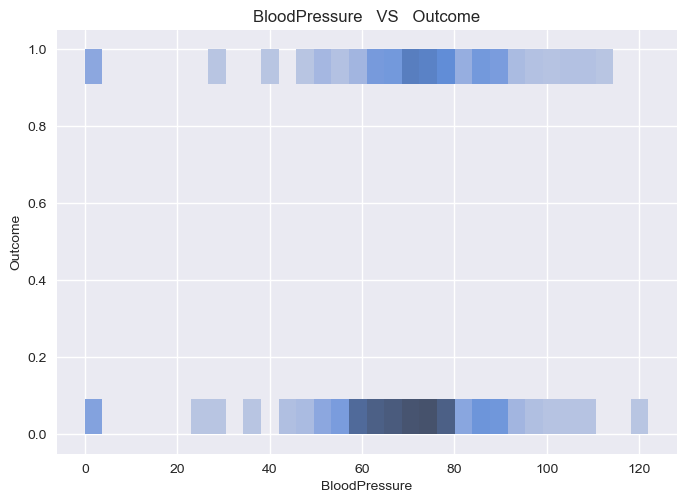

-----------------------------------------------------------------------------------------


In [24]:

sns.histplot(df2 , x="BloodPressure" , y="SkinThickness")
plt.title("BloodPressure   VS   SkinThickness")

plt.show()
print("-----------------------------------------------------------------------------------------")


sns.histplot(df2 , x="BloodPressure" , y="Insulin")
plt.title("BloodPressure   VS   Insulin")

plt.show()
print("-----------------------------------------------------------------------------------------")


sns.histplot(df2 , x="BloodPressure" , y="BMI")
plt.title("BloodPressure   VS   BMI")

plt.show()
print("-----------------------------------------------------------------------------------------")


sns.histplot(df2 , x="BloodPressure" , y="DiabetesPedigreeFunction")
plt.title("BloodPressure   VS   DiabetesPedigreeFunction")

plt.show()
print("-----------------------------------------------------------------------------------------")


sns.histplot(df2 , x="BloodPressure" , y="Age")
plt.title("BloodPressure   VS   Age")

plt.show()
print("-----------------------------------------------------------------------------------------")


sns.histplot(df2 , x="BloodPressure" , y="Outcome")
plt.title("BloodPressure   VS   Outcome")

plt.show()
print("-----------------------------------------------------------------------------------------")


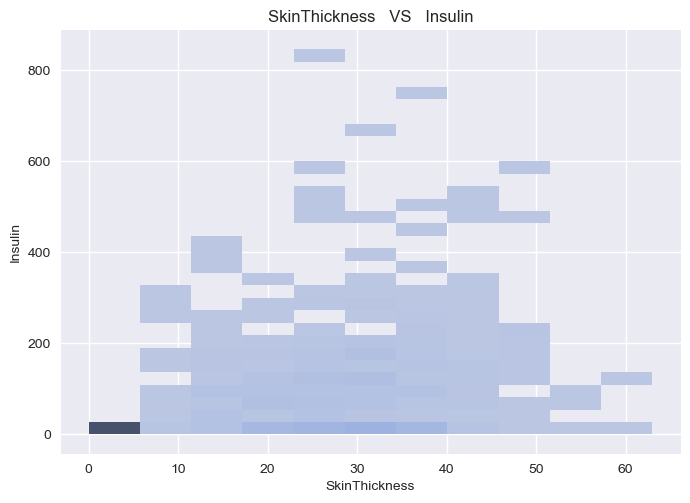

-----------------------------------------------------------------------------------------


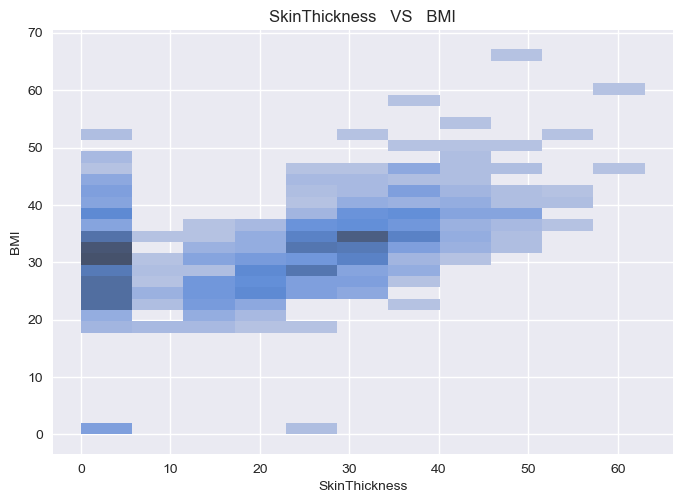

-----------------------------------------------------------------------------------------


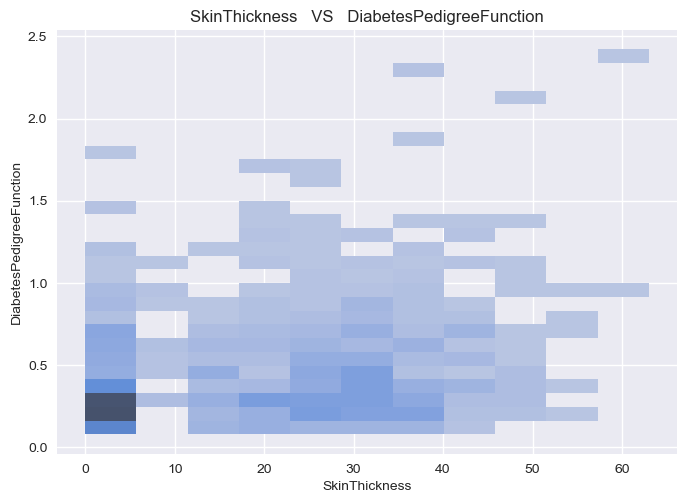

-----------------------------------------------------------------------------------------


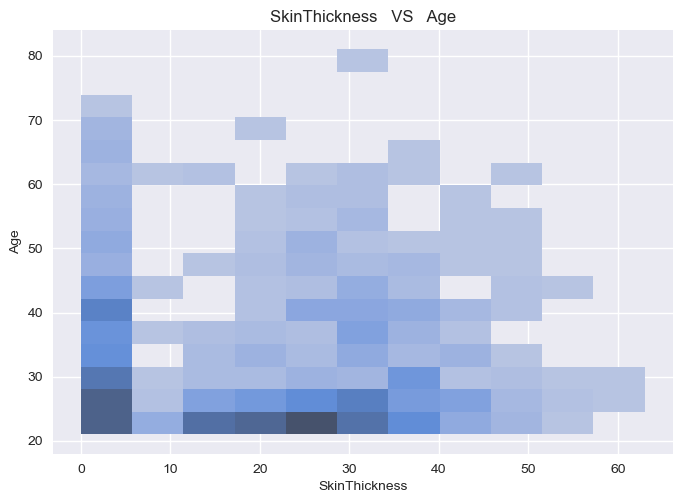

-----------------------------------------------------------------------------------------


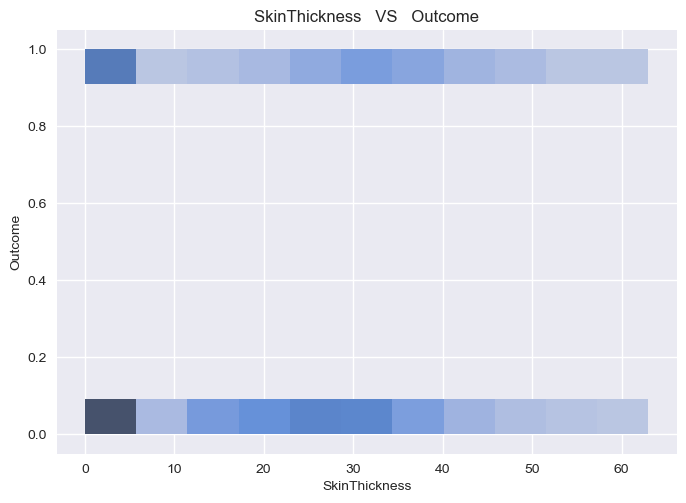

-----------------------------------------------------------------------------------------


In [25]:


sns.histplot(df2 , x="SkinThickness" , y="Insulin")
plt.title("SkinThickness   VS   Insulin")

plt.show()
print("-----------------------------------------------------------------------------------------")


sns.histplot(df2 , x="SkinThickness" , y="BMI")
plt.title("SkinThickness   VS   BMI")

plt.show()
print("-----------------------------------------------------------------------------------------")


sns.histplot(df2 , x="SkinThickness" , y="DiabetesPedigreeFunction")
plt.title("SkinThickness   VS   DiabetesPedigreeFunction")

plt.show()
print("-----------------------------------------------------------------------------------------")


sns.histplot(df2 , x="SkinThickness" , y="Age")
plt.title("SkinThickness   VS   Age")

plt.show()
print("-----------------------------------------------------------------------------------------")


sns.histplot(df2 , x="SkinThickness" , y="Outcome")
plt.title("SkinThickness   VS   Outcome")

plt.show()
print("-----------------------------------------------------------------------------------------")


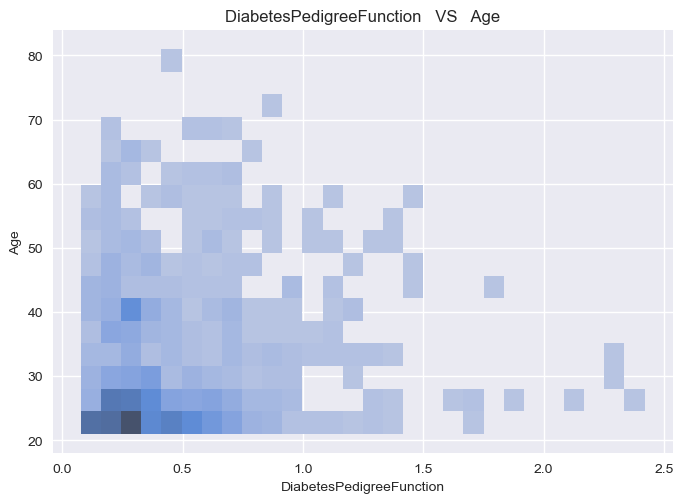

-----------------------------------------------------------------------------------------


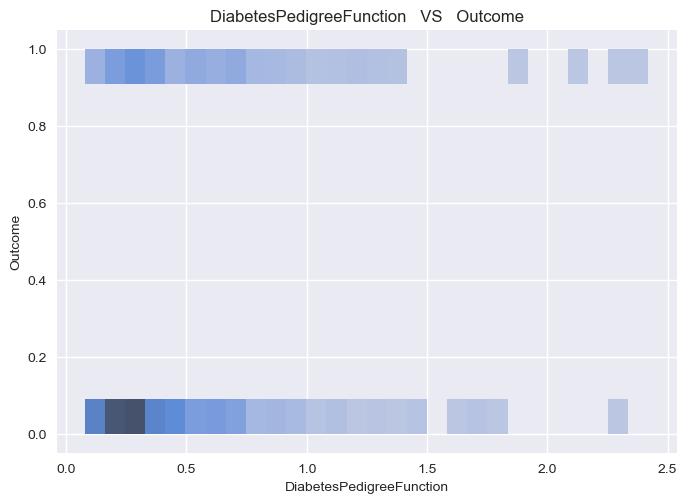

-----------------------------------------------------------------------------------------


In [26]:

sns.histplot(df2 , x="DiabetesPedigreeFunction" , y="Age")
plt.title("DiabetesPedigreeFunction   VS   Age")

plt.show()
print("-----------------------------------------------------------------------------------------")


sns.histplot(df2 , x="DiabetesPedigreeFunction" , y="Outcome")
plt.title("DiabetesPedigreeFunction   VS   Outcome")

plt.show()
print("-----------------------------------------------------------------------------------------")


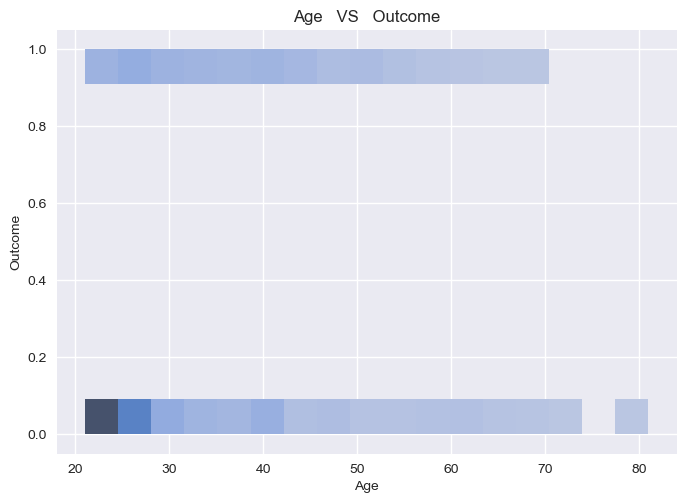

-----------------------------------------------------------------------------------------


In [27]:
sns.histplot(df2 , x="Age" , y="Outcome")
plt.title("Age   VS   Outcome")

plt.show()
print("-----------------------------------------------------------------------------------------")


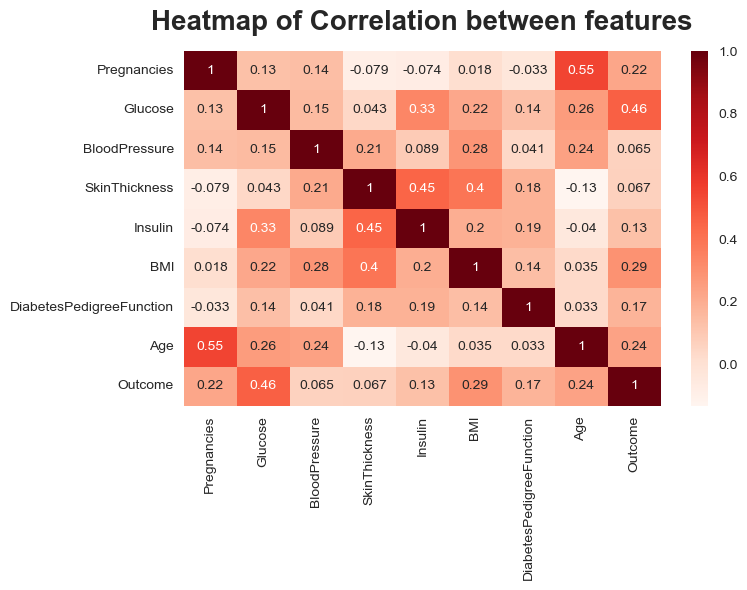

In [28]:
plt.figure(figsize=(8,6))
sns.heatmap(df2.corr(numeric_only=True), annot=True, cmap='Reds')
plt.title('Heatmap of Correlation between features', fontsize=20, fontweight='bold' , pad = 15)
plt.tight_layout()
plt.show()

<Axes: xlabel='BMI', ylabel='DiabetesPedigreeFunction'>

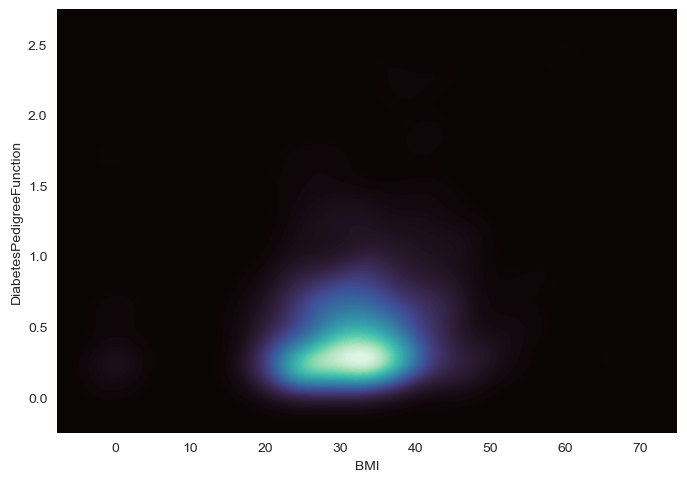

In [29]:
sns.kdeplot(
    data=df2 , y="DiabetesPedigreeFunction" , x="BMI"  ,
    fill=True , thresh=0 , levels=100 , cmap="mako" 
)

In [30]:
df2

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,1,113,64,35,0,33.6,0.543,21,1
1,2,84,0,0,0,0.0,0.304,21,0
2,0,125,96,0,0,22.5,0.262,21,0
3,1,0,74,20,23,27.7,0.299,21,0
4,0,94,70,27,115,43.5,0.347,21,0
...,...,...,...,...,...,...,...,...,...
763,5,132,80,0,0,26.8,0.186,69,0
764,5,136,82,0,0,0.0,0.640,69,0
765,4,145,82,18,0,32.5,0.235,70,1
766,2,119,0,0,0,19.6,0.832,72,0


<Axes: xlabel='Glucose', ylabel='DiabetesPedigreeFunction'>

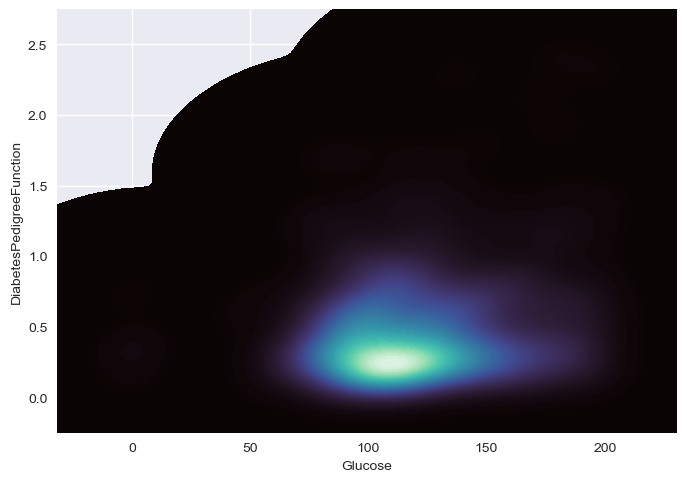

In [31]:
sns.kdeplot(
    data=df2 , x="Glucose" , y="DiabetesPedigreeFunction"  ,
    fill=True , thresh=0
    , levels=100 , cmap="mako", 
)

<Axes: xlabel='BloodPressure', ylabel='DiabetesPedigreeFunction'>

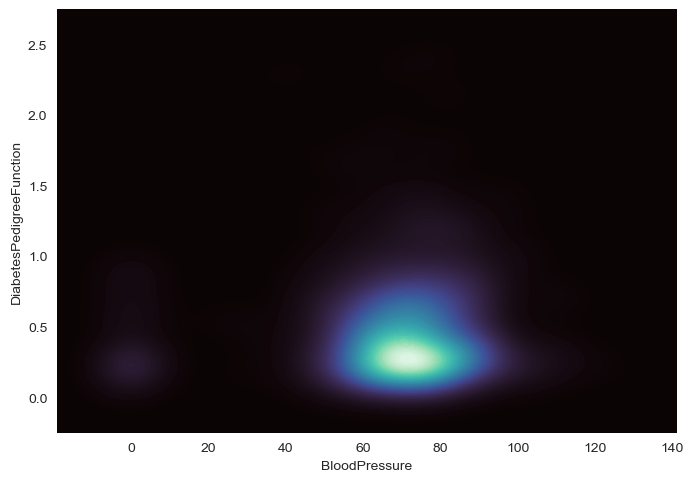

In [32]:
sns.kdeplot(
    data=df2 , x="BloodPressure" , y="DiabetesPedigreeFunction"  ,
    fill=True , thresh=0
    , levels=100 , cmap="mako", 
)

<Axes: xlabel='SkinThickness', ylabel='DiabetesPedigreeFunction'>

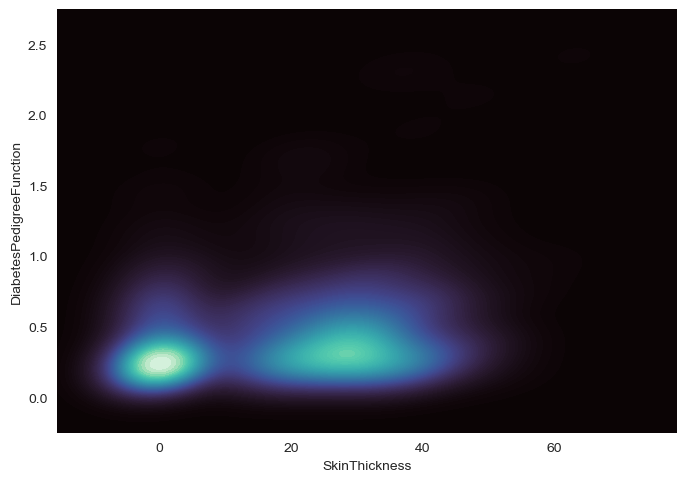

In [33]:
sns.kdeplot(
    data=df2 , x="SkinThickness" , y="DiabetesPedigreeFunction"  ,
    fill=True , thresh=0
    , levels=100 , cmap="mako", 
)

<Axes: xlabel='Insulin', ylabel='DiabetesPedigreeFunction'>

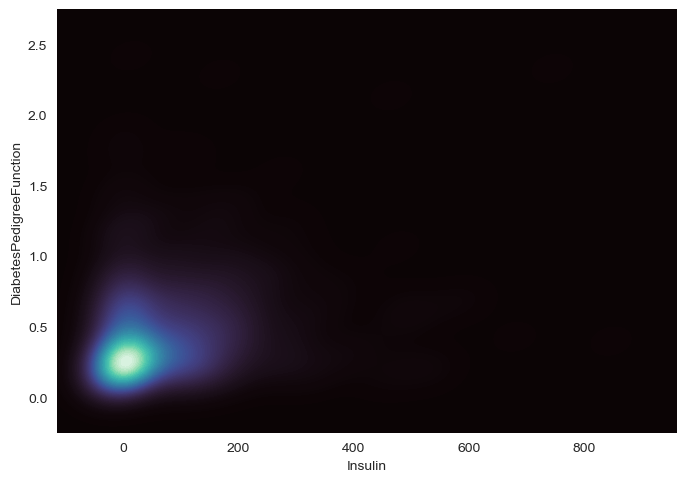

In [34]:
sns.kdeplot(
    data=df2 , x="Insulin" , y="DiabetesPedigreeFunction"  ,
    fill=True , thresh=0
    , levels=100 , cmap="mako", 
)

<Axes: xlabel='BMI', ylabel='DiabetesPedigreeFunction'>

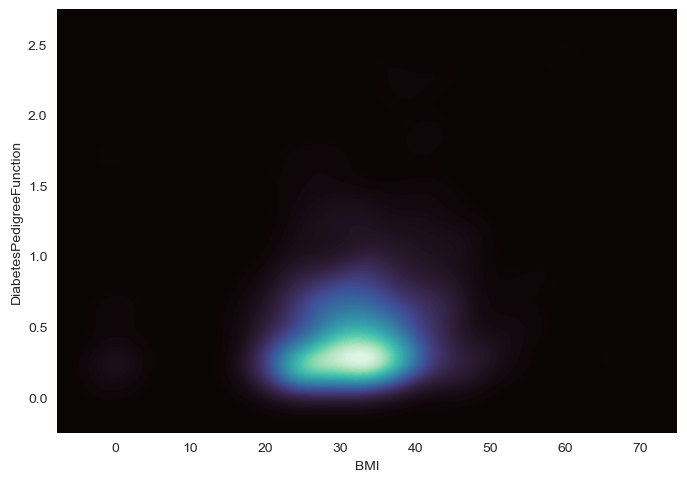

In [35]:
sns.kdeplot(
    data=df2 , x="BMI" , y="DiabetesPedigreeFunction"  ,
    fill=True , thresh=0
    , levels=100 , cmap="mako", 
)

<Axes: xlabel='DiabetesPedigreeFunction', ylabel='Outcome'>

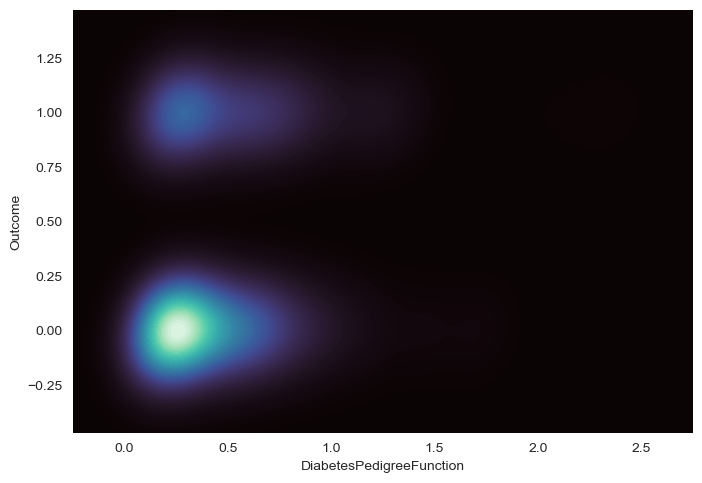

In [36]:
sns.kdeplot(
    data=df2 , y="Outcome" , x="DiabetesPedigreeFunction"  ,
    fill=True , thresh=0
    , levels=100 , cmap="mako", 
)

In [37]:
#  crolation

df2.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.131674,0.141343,-0.079436,-0.074067,0.017933,-0.033309,0.548341,0.223189
Glucose,0.131674,1.000000,0.153013,0.042882,0.334854,0.220839,0.136886,0.257875,0.464625
BloodPressure,0.141343,0.153013,1.000000,0.210424,0.089003,0.281807,0.041249,0.240321,0.065065
SkinThickness,-0.079436,0.042882,0.210424,1.000000,0.448507,0.396713,0.184884,-0.132288,0.067136
Insulin,-0.074067,0.334854,0.089003,0.448507,1.000000,0.198247,0.185422,-0.040122,0.131984
BMI,0.017933,0.220839,0.281807,0.396713,0.198247,1.000000,0.140527,0.035286,0.292461
DiabetesPedigreeFunction,-0.033309,0.136886,0.041249,0.184884,0.185422,0.140527,1.000000,0.032698,0.173512
Age,0.548341,0.257875,0.240321,-0.132288,-0.040122,0.035286,0.032698,1.000000,0.235203
Outcome,0.223189,0.464625,0.065065,0.067136,0.131984,0.292461,0.173512,0.235203,1.000000


<div style="
  margin: 40px 0 25px 0;
  text-align: center;
  font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
">
  <h2 style="
    font-size: 24px;
    font-weight: 700;
    color: #1e3a8a;
    margin: 0 0 10px 0;
    letter-spacing: 0.3px;
  ">
    Building the Model
  </h2>
  <div style="
    width: 160px;
    height: 4px;
    background: linear-gradient(90deg, #3b82f6, #8b5cf6);
    margin: 0 auto;
    border-radius: 4px;
  "></div>
</div>

In [39]:
x = df2.drop(["Outcome"] , axis=1)
y = df2.Outcome.values.reshape(-1,1)

In [40]:
x_train ,x_test , y_train , y_test = train_test_split(x , y , test_size=0.2 , random_state=1)

print(" x_train  :" , x_train.shape)
print(" x_test  :" , x_test.shape)
print(" y_train  :" , y_train.shape)
print(" y_test  :" , y_test.shape)

 x_train  : (613, 8)
 x_test  : (154, 8)
 y_train  : (613, 1)
 y_test  : (154, 1)


In [41]:
model = LogisticRegression(solver='liblinear')
model.fit(x_train , y_train)

y_pred = model.predict(x_test)

In [42]:
#  evaluate :

In [45]:
print("Accuracy : " , metrics.accuracy_score(y_test , y_pred))

Accuracy :  0.7337662337662337


<div style="
  margin: 25px 0;
  padding: 14px 18px;
  background: #f0f7ff;
  border-left: 5px solid #3b82f6;
  border-radius: 6px;
  font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
  font-size: 16px;
  color: #1e3a8a;
  line-height: 1.5;
">
  <strong>Score:</strong> 73%
</div>

<div style="
  margin: 40px 0 25px 0;
  text-align: center;
  font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
">
  <h2 style="
    font-size: 24px;
    font-weight: 700;
    color: #1e3a8a;
    margin: 0 0 10px 0;
    letter-spacing: 0.3px;
  ">
    Visual Evaluation of the Model
  </h2>
  <div style="
    width: 180px;
    height: 4px;
    background: linear-gradient(90deg, #3b82f6, #8b5cf6);
    margin: 0 auto;
    border-radius: 4px;
  "></div>
</div>

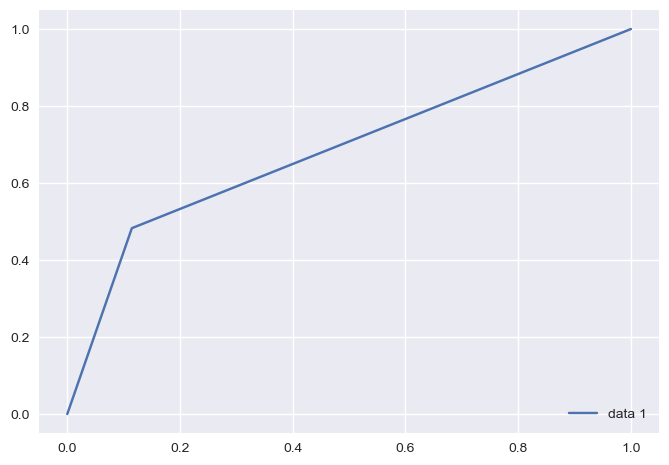

In [48]:
fpr , tpr , _ = metrics.roc_curve(y_test ,y_pred)
plt.plot(fpr , tpr , label='data 1')
plt.legend(loc=4)
plt.show()

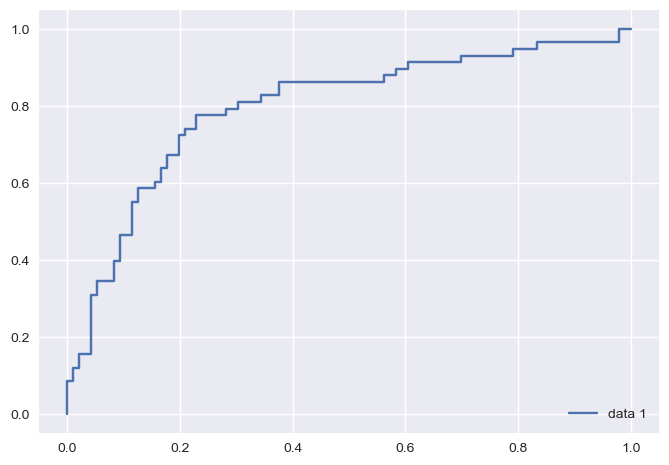

In [49]:
y_pred_proba = model.predict_proba(x_test)[::,1]

fpr , tpr , _ = metrics.roc_curve(y_test , y_pred_proba)
plt.plot(fpr , tpr , label="data 1")
plt.legend(loc=4)
plt.show()

In [50]:
from sklearn.metrics import ConfusionMatrixDisplay


In [51]:
model.classes_

array([0, 1], dtype=int64)

In [52]:
model.intercept_

array([-5.52438223])

In [53]:
model.coef_

array([[ 1.21766282e-01,  3.13403678e-02, -1.97195242e-02,
         2.68680027e-04, -5.23620935e-04,  4.47671807e-02,
         6.68795364e-01,  3.83415420e-03]])

<div style="
  margin: 40px 0 25px 0;
  text-align: center;
  font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
">
  <h2 style="
    font-size: 22px;
    font-weight: 700;
    color: #1e3a8a;
    margin: 0 0 10px 0;
    letter-spacing: 0.3px;
  ">
    Re-Modeling with Proba to Improve Model Performance
  </h2>
  <div style="
    width: 200px;
    height: 4px;
    background: linear-gradient(90deg, #3b82f6, #8b5cf6);
    margin: 0 auto;
    border-radius: 4px;
  "></div>
</div>

In [55]:
model.predict_proba(x)  


array([[0.76241213, 0.23758787],
       [0.91407421, 0.08592579],
       [0.90351519, 0.09648481],
       ...,
       [0.55592439, 0.44407561],
       [0.46043596, 0.53956404],
       [0.48325368, 0.51674632]])

<div style="
  margin: 25px 0;
  padding: 14px 18px;
  background: #f0f7ff;
  border-left: 5px solid #3b82f6;
  border-radius: 6px;
  font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
  font-size: 16px;
  color: #1e3a8a;
  line-height: 1.5;
">
  <strong>Note:</strong> <code>model.predict_proba(x)</code> → Left side shows the probability of class 0, right side shows the probability of class 1.
</div>

In [56]:
model.predict(x)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0,

In [57]:
model.score(x,y)

0.7757496740547588

<div style="
  margin: 25px 0;
  padding: 14px 18px;
  background: #f0f7ff;
  border-left: 5px solid #3b82f6;
  border-radius: 6px;
  font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
  font-size: 16px;
  color: #1e3a8a;
  line-height: 1.5;
">
  <strong>Score:</strong> 77%
</div>

In [61]:
confusion_matrix(y , model.predict(x))

array([[453,  47],
       [125, 142]], dtype=int64)

<div style="
  margin: 40px 0 25px 0;
  text-align: center;
  font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
">
  <h2 style="
    font-size: 24px;
    font-weight: 700;
    color: #1e3a8a;
    margin: 0 0 10px 0;
    letter-spacing: 0.3px;
  ">
    Analyzing the Model
  </h2>
  <div style="
    width: 160px;
    height: 4px;
    background: linear-gradient(90deg, #3b82f6, #8b5cf6);
    margin: 0 auto;
    border-radius: 4px;
  "></div>
</div>

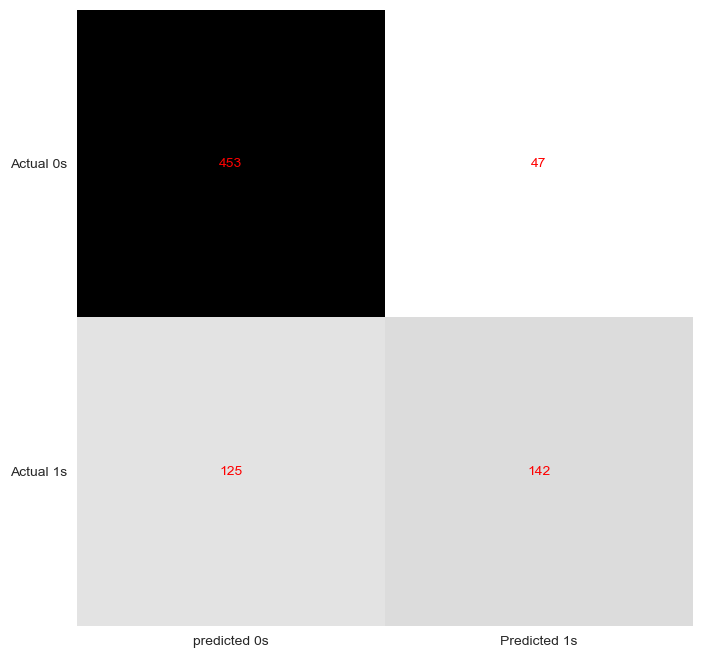

In [71]:
cm = confusion_matrix(y,model.predict(x))

fig , ax = plt.subplots(figsize=(8,8))
ax.imshow(cm)
ax.grid(False)
ax.xaxis.set(ticks=(0,1) , ticklabels=('predicted 0s' , 'Predicted 1s'))
ax.yaxis.set(ticks=(0,1) , ticklabels=('Actual 0s' , 'Actual 1s'))

ax.set_ylim(1.5 , -0.5)

for i in range(2) :
    for j in range (2) :
        ax.text(j, i , cm[i ,j] , ha='center' , va='center' , color="red")
        
plt.show()

<div style="
  margin: 40px 0 25px 0;
  text-align: center;
  font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
">
  <h2 style="
    font-size: 24px;
    font-weight: 700;
    color: #1e3a8a;
    margin: 0 0 10px 0;
    letter-spacing: 0.3px;
  ">
    Analysis with Classification Report
  </h2>
  <div style="
    width: 200px;
    height: 4px;
    background: linear-gradient(90deg, #3b82f6, #8b5cf6);
    margin: 0 auto;
    border-radius: 4px;
  "></div>
</div>

In [73]:
print(classification_report(y , model.predict(x)))

              precision    recall  f1-score   support

           0       0.78      0.91      0.84       500
           1       0.75      0.53      0.62       267

    accuracy                           0.78       767
   macro avg       0.77      0.72      0.73       767
weighted avg       0.77      0.78      0.76       767



In [78]:
df3 = pd.DataFrame({'Pregnancies':[0],
                   'Glucose':[80],
                   'BloodPressure':[72],
                   'SkinThickness' :[0],
                   'Insulin':[0],
                   'BMI':[23],
                   'DiabetesPedigreeFunction':[0.5],
                   'Age':[30],
                   'Outcome':[0]
                   
})

In [88]:
df2

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,1,113,64,35,0,33.6,0.543,21,1
1,2,84,0,0,0,0.0,0.304,21,0
2,0,125,96,0,0,22.5,0.262,21,0
3,1,0,74,20,23,27.7,0.299,21,0
4,0,94,70,27,115,43.5,0.347,21,0
...,...,...,...,...,...,...,...,...,...
763,5,132,80,0,0,26.8,0.186,69,0
764,5,136,82,0,0,0.0,0.640,69,0
765,4,145,82,18,0,32.5,0.235,70,1
766,2,119,0,0,0,19.6,0.832,72,0


In [80]:
df4 = df2.append(df3)
df4

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,1,113,64,35,0,33.6,0.543,21,1
1,2,84,0,0,0,0.0,0.304,21,0
2,0,125,96,0,0,22.5,0.262,21,0
3,1,0,74,20,23,27.7,0.299,21,0
4,0,94,70,27,115,43.5,0.347,21,0
...,...,...,...,...,...,...,...,...,...
764,5,136,82,0,0,0.0,0.640,69,0
765,4,145,82,18,0,32.5,0.235,70,1
766,2,119,0,0,0,19.6,0.832,72,0
767,9,134,74,33,60,25.9,0.460,81,0


In [94]:
x_train=df4[['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age']][:767]
y_train = df4[['Outcome']][:767].values.reshape(-1,1)

x_test=df4[['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age']][767:]

In [95]:
x_test

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0,80,72,0,0,23.0,0.5,30


In [102]:
model2 = LogisticRegression(solver='liblinear',C=10 , random_state=0)

model2.fit(x_train , y_train.ravel())

y_pred = model2.predict(x_test)
y_pred

array([0], dtype=int64)

## Outepute : 0

<div style="
  margin: 40px 0 25px 0;
  text-align: center;
  font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
">
  <h2 style="
    font-size: 24px;
    font-weight: 700;
    color: #1e3a8a;
    margin: 0 0 10px 0;
    letter-spacing: 0.3px;
  ">
    Modeling Completed with 77% Accuracy
  </h2>
  <div style="
    width: 200px;
    height: 4px;
    background: linear-gradient(90deg, #3b82f6, #8b5cf6);
    margin: 0 auto;
    border-radius: 4px;
  "></div>
</div>